In [12]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

In [13]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [14]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

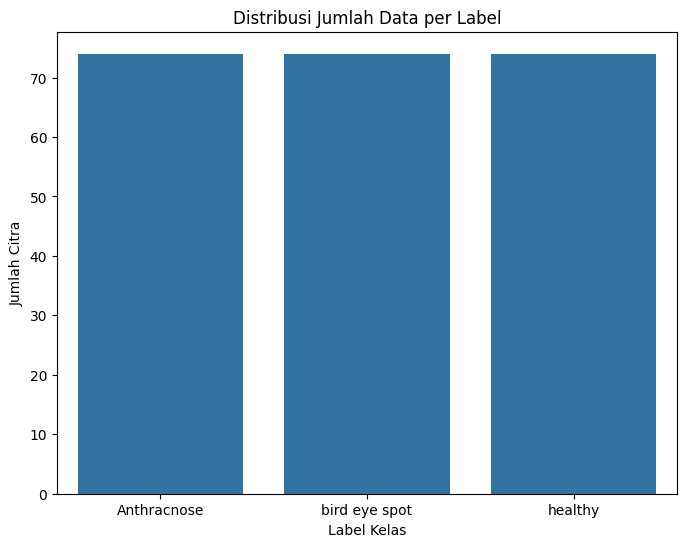

Total jumlah citra dalam dataset: 222
Total jumlah label dalam dataset: 222
Jumlah kelas unik: 3

Jumlah citra per kelas:
Anthracnose      74
bird eye spot    74
healthy          74
Name: count, dtype: int64


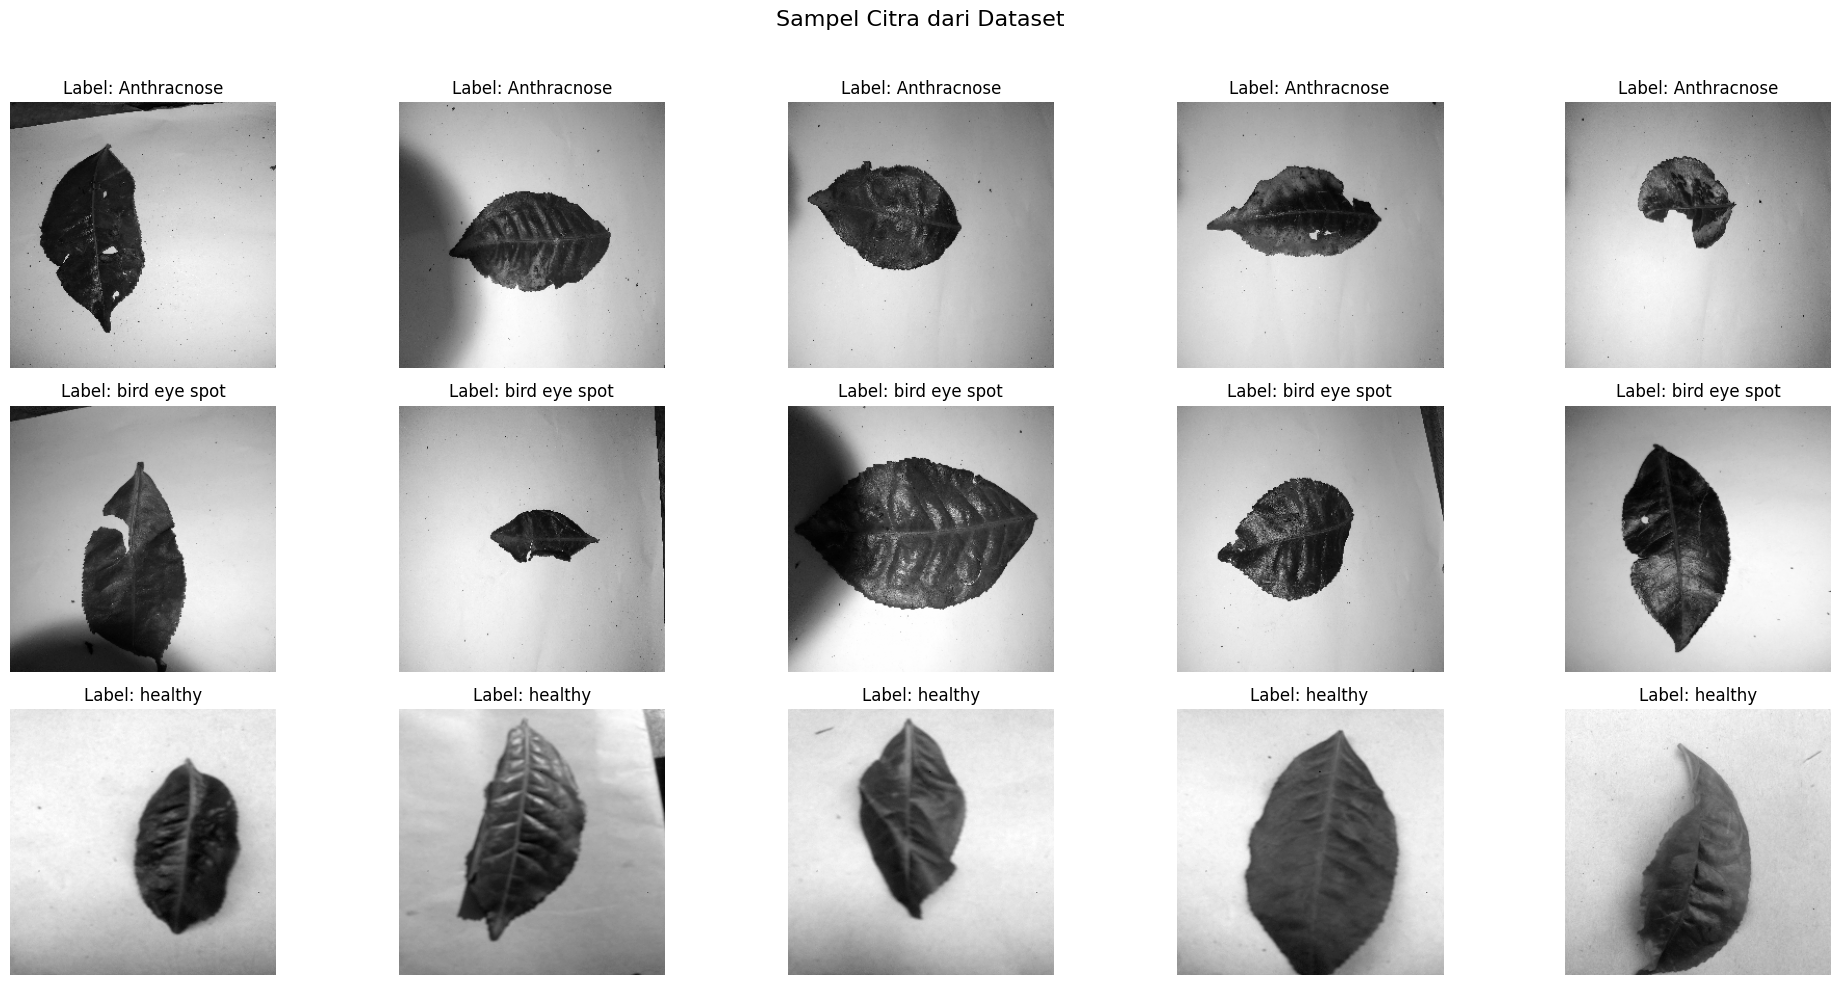

In [15]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'normal' dan 'tumor'
Anthracnose_indices = np.where(labels == 'Anthracnose')[0]
bird_eye_spot_indices = np.where(labels == 'bird eye spot')[0]
healthy_indices = np.where(labels == 'healthy')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(Anthracnose_indices) >= num_samples_to_show:
    sample_Anthracnose_indices = np.random.choice(Anthracnose_indices, num_samples_to_show, replace=False)
else:
    sample_Anthracnose_indices = Anthracnose_indices

if len(bird_eye_spot_indices) >= num_samples_to_show:
    sample_bird_eye_spot_indices = np.random.choice(bird_eye_spot_indices, num_samples_to_show, replace=False)
else:
    sample_bird_eye_spot_indices = bird_eye_spot_indices

if len(healthy_indices) >= num_samples_to_show:
    sample_healthy_indices = np.random.choice(healthy_indices, num_samples_to_show, replace=False)
else:
    sample_healthy_indices = healthy_indices

# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_Anthracnose_indices, sample_bird_eye_spot_indices, sample_healthy_indices))

# Ubah bagian for loop untuk plotting sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset', fontsize=16)

# Gunakan 3 baris (sesuai jumlah kelas) dan 5 kolom (sesuai num_samples_to_show)
for i, index in enumerate(sample_indices):
    plt.subplot(3, num_samples_to_show, i + 1) 
    plt.imshow(data[index], cmap='gray') 
    plt.title(f"Label: {labels[index]}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [16]:
from collections import Counter

# -----------------------------
# 1. Menampilkan Jumlah Data
print("Jumlah total gambar:", len(data))
print("Jumlah kelas:", len(np.unique(labels)))
print("Distribusi per kelas:", Counter(labels))

Jumlah total gambar: 222
Jumlah kelas: 3
Distribusi per kelas: Counter({np.str_('Anthracnose'): 74, np.str_('bird eye spot'): 74, np.str_('healthy'): 74})


In [17]:
def fungsi_dua(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [19]:
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(3, 4, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB))
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
img_grey = []
for img in images:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)